# 📊 FIAP - Feature Engineering
## Tratamento de Dados Numéricos: Técnicas de Discretização

---

### 📋 **Informações do Projeto**
- **Curso:** Pós-graduação em Data Science & Artificial Intelligence
- **Disciplina:** Feature Engineering
- **Aula:** 2 - Encoding, Discretização e Criação de Features
- **Autor:** Filipe Pacheco

---

### 🎯 **Objetivos do Projeto**
Este notebook demonstra técnicas fundamentais de discretização para variáveis numéricas:
- **Equal Width Binning:** Divisão em intervalos de igual largura
- **Equal Frequency Binning:** Divisão em intervalos com igual frequência
- **K-Means Clustering:** Discretização baseada em agrupamento
- **Comparação de Métodos:** Avaliação do impacto de diferentes abordagens de discretização

---

### 📊 **Dataset Utilizado**
**Wine Quality Dataset** - Dados de qualidade de vinhos tintos
- **Fonte:** UCI Machine Learning Repository - Região do Douro, Portugal
- **Registros:** Dataset com características químicas de vinhos
- **Features:** 11 atributos químicos + 1 variável target (qualidade)
- **Objetivo:** Predição da qualidade do vinho através de discretização de variáveis

---

### 🔧 **Principais Técnicas Aplicadas**
1. **Equal Width Binning:**
   - Divisão de variáveis numéricas em intervalos de largura igual
   - Aplicação em diferentes números de bins

2. **Equal Frequency Binning:**
   - Divisão de variáveis numéricas em intervalos com frequência igual
   - Balanceamento de observações por bin

3. **K-Means Clustering:**
   - Discretização baseada em agrupamento não supervisionado
   - Criação de bins através de centroides

4. **Validação:**
   - Comparação de modelos com diferentes estratégias de discretização
   - Métricas de performance e visualizações comparativas

---

# 1. Importação e Configuração das Bibliotecas

Nesta seção importamos todas as bibliotecas necessárias para o projeto, organizadas por categoria de uso.

In [1]:
# =============================================================================
# BIBLIOTECAS DE MANIPULAÇÃO E ANÁLISE DE DADOS
# =============================================================================
import pandas as pd              # Manipulação e análise de dados estruturados (DataFrames)
import numpy as np               # Operações matemáticas e arrays multidimensionais

# =============================================================================
# BIBLIOTECAS DE MACHINE LEARNING - SCIKIT-LEARN
# =============================================================================
from sklearn.cluster import KMeans                     # Algoritmo de clustering K-Means
from sklearn.preprocessing import KBinsDiscretizer     # Discretização de variáveis numéricas
from sklearn.model_selection import train_test_split   # Divisão de dados em treino/teste
from sklearn.linear_model import LinearRegression      # Modelo de regressão linear
from sklearn.metrics import mean_squared_error, r2_score  # Métricas de avaliação para regressão

# =============================================================================
# BIBLIOTECAS DE VISUALIZAÇÃO
# =============================================================================
import matplotlib.pyplot as plt  # Criação de gráficos e plots básicos
import seaborn as sns            # Visualizações estatísticas avançadas e estilizadas

# =============================================================================
# CONFIGURAÇÕES GERAIS
# =============================================================================
# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")          # Configurar paleta de cores
plt.rcParams['figure.figsize'] = (10, 6)  # Configurar tamanho padrão das figuras

# 2. Carregamento e Exploração do Dataset

## 2.1. Descrição do Dataset

Para este exemplo, utilizaremos o dataset **"Wine Quality"** disponível no UCI Machine Learning Repository. Este dataset contém informações sobre a qualidade de vinhos tintos da região do Douro, em Portugal, com base em diversas características químicas. É amplamente utilizado em estudos de machine learning para predição e classificação da qualidade do vinho.

### **Principais Características do Dataset:**
- **fixed acidity:** Acidez fixa do vinho (ácidos não voláteis)
- **volatile acidity:** Acidez volátil do vinho (ácidos que podem evaporar)
- **citric acid:** Conteúdo de ácido cítrico no vinho
- **residual sugar:** Açúcar residual após fermentação
- **chlorides:** Concentração de cloretos (sal) no vinho
- **free sulfur dioxide:** Quantidade de dióxido de enxofre livre
- **total sulfur dioxide:** Quantidade total de dióxido de enxofre
- **density:** Densidade do vinho (relacionada ao teor alcoólico e açúcar)
- **pH:** Nível de acidez/alcalinidade do vinho (escala 0-14)
- **sulphates:** Concentração de sulfatos (conservante)
- **alcohol:** Percentual de álcool no vinho
- **quality:** Qualidade do vinho (variável alvo), avaliada em escala de 0 a 10

### **Importância das Variáveis:**
- **Acidez Fixa e Volátil:** Afetam o sabor do vinho; altos níveis de acidez volátil podem ser indesejáveis
- **Ácido Cítrico:** Contribui para a frescura e sabor cítrico do vinho
- **Açúcar Residual:** Determina o nível de doçura; níveis mais altos indicam vinhos doces
- **Cloretos:** Representam o teor de sal; altos níveis podem indicar defeitos na produção
- **Dióxido de Enxofre (Livre/Total):** Usado como conservante; protege contra oxidação e bactérias
- **Densidade:** Relacionada ao conteúdo de açúcar e álcool; importante para classificação
- **pH:** Mede a acidez total; influencia estabilidade, cor e sabor
- **Sulfatos:** Contribuem para a conservação e podem afetar o aroma
- **Álcool:** Contribui para o corpo, sabor e sensação na boca
- **Qualidade:** Avaliação sensorial pelos especialistas, sendo nossa variável target

### **Fonte do Dataset:**
- O dataset está originalmente disponível em: **UCI Machine Learning Repository - Wine Quality Data Set**
- Para carregar o dataset em um DataFrame do pandas:

```python
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, delimiter=';')
```

In [2]:
df = pd.read_csv("datasets/wine-quality-red.csv")

# Visualizamos as primeiras linhas do dataset
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# 3. Análise Exploratória Inicial do Dataset

Nesta seção vamos explorar as características básicas do dataset e entender melhor sua estrutura.

In [3]:
# Visualizando informações gerais sobre o dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
# Vamos observar algumas estatísticas descritivas do dataset para entender melhor os dados.
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


# 3.1. Preparação dos Dados para Evitar Vazamento

Antes de aplicar as técnicas de discretização, vamos separar os dados em conjuntos de treino e teste para evitar vazamento de informações durante o processo de discretização.

In [5]:
# Separação dos dados em features (X) e target (y)
X = df.drop(columns=['quality'])  # Todas as características exceto a variável target
y = df['quality']                 # Variável target (qualidade do vinho)

# Divisão em conjuntos de treino e teste (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# 4. Equal Width Binning

A técnica de **Equal Width Binning** divide os dados em intervalos de largura igual, proporcionando uma distribuição uniforme dos intervalos, mas não necessariamente uma distribuição uniforme das observações.

## 4.1. Aplicação de Equal Width Binning

In [6]:
# Vamos discretizar a variável 'alcohol' em 5 bins de largura igual.
# Ajustamos o discretizador apenas nos dados de treino
equal_width_discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
X_train['alcohol_equal_width'] = equal_width_discretizer.fit_transform(X_train[['alcohol']])
X_test['alcohol_equal_width'] = equal_width_discretizer.transform(X_test[['alcohol']])

## 4.2. Visualização dos Resultados

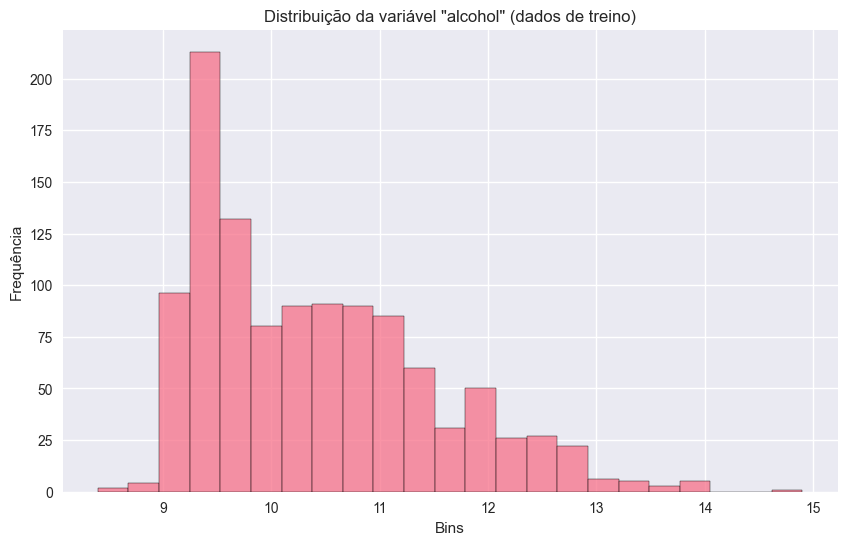

In [7]:
# Plotando a distribuição dos dados não discretizados
plt.figure(figsize=(10, 6))
sns.histplot(X_train['alcohol'], kde=False)
plt.title('Distribuição da variável "alcohol" (dados de treino)')
plt.xlabel('Bins')
plt.ylabel('Frequência')
plt.show()

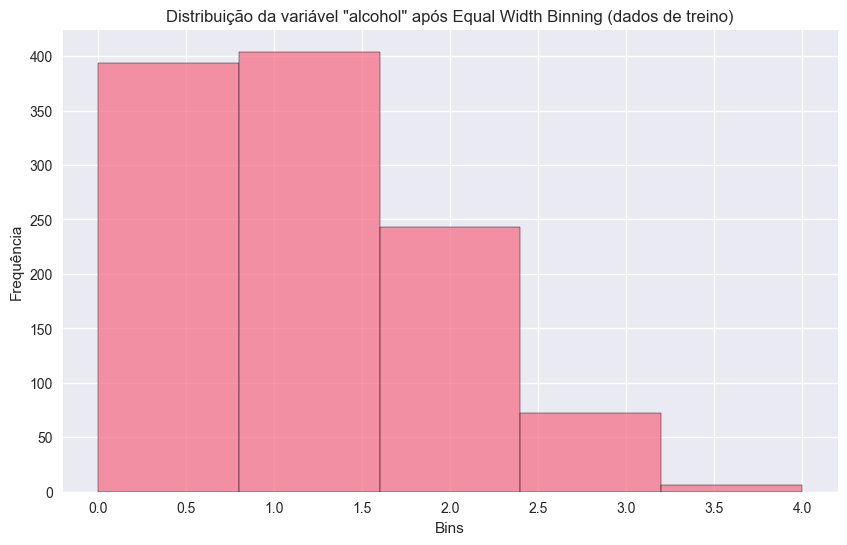

In [8]:
# Plotando a distribuição dos dados discretizados
plt.figure(figsize=(10, 6))
sns.histplot(X_train['alcohol_equal_width'], bins=5, kde=False)
plt.title('Distribuição da variável "alcohol" após Equal Width Binning (dados de treino)')
plt.xlabel('Bins')
plt.ylabel('Frequência')
plt.show()

# 5. Equal Frequency Binning

A técnica de **Equal Frequency Binning** divide os dados em intervalos com a mesma frequência (mesmo número de observações), garantindo uma distribuição balanceada das observações entre os bins.

## 5.1. Aplicação de Equal Frequency Binning

In [9]:
# Vamos discretizar a variável 'alcohol' em 5 bins de frequência igual.
# Ajustamos o discretizador apenas nos dados de treino
equal_frequency_discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
X_train['alcohol_equal_frequency'] = equal_frequency_discretizer.fit_transform(X_train[['alcohol']])
X_test['alcohol_equal_frequency'] = equal_frequency_discretizer.transform(X_test[['alcohol']])

## 5.2. Visualização dos Resultados

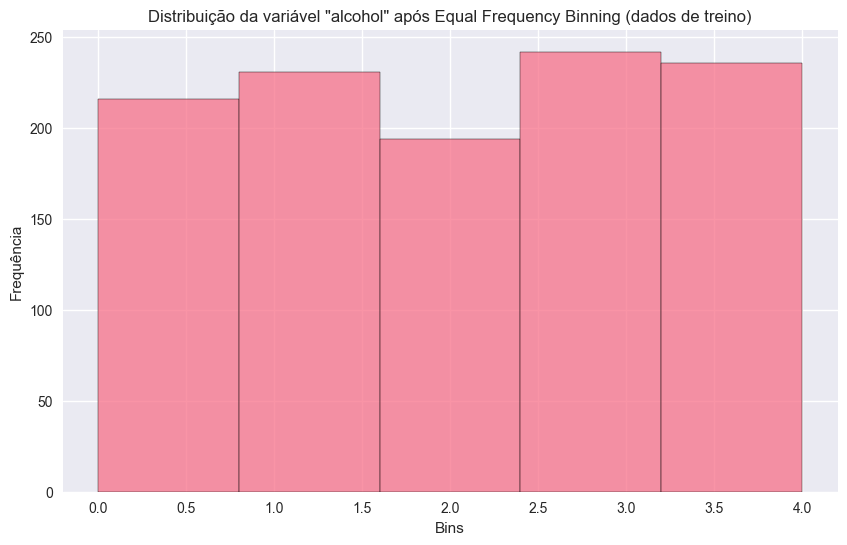

In [10]:
# Plotando a distribuição dos dados discretizados
plt.figure(figsize=(10, 6))
sns.histplot(X_train['alcohol_equal_frequency'], bins=5, kde=False)
plt.title('Distribuição da variável "alcohol" após Equal Frequency Binning (dados de treino)')
plt.xlabel('Bins')
plt.ylabel('Frequência')
plt.show()

# 6. K-Means Clustering para Discretização

A técnica de **K-Means Clustering** agrupa os dados em K clusters baseados na similaridade dos valores, criando bins com base nos centroides dos clusters formados.

## 6.1. Aplicação de K-Means Clustering

In [11]:
# Vamos discretizar a variável 'alcohol' em 5 clusters.
# Ajustamos o K-Means apenas nos dados de treino
kmeans = KMeans(n_clusters=5, random_state=0)
X_train['alcohol_kmeans'] = kmeans.fit_predict(X_train[['alcohol']])
X_test['alcohol_kmeans'] = kmeans.predict(X_test[['alcohol']])

## 6.2. Visualização dos Resultados

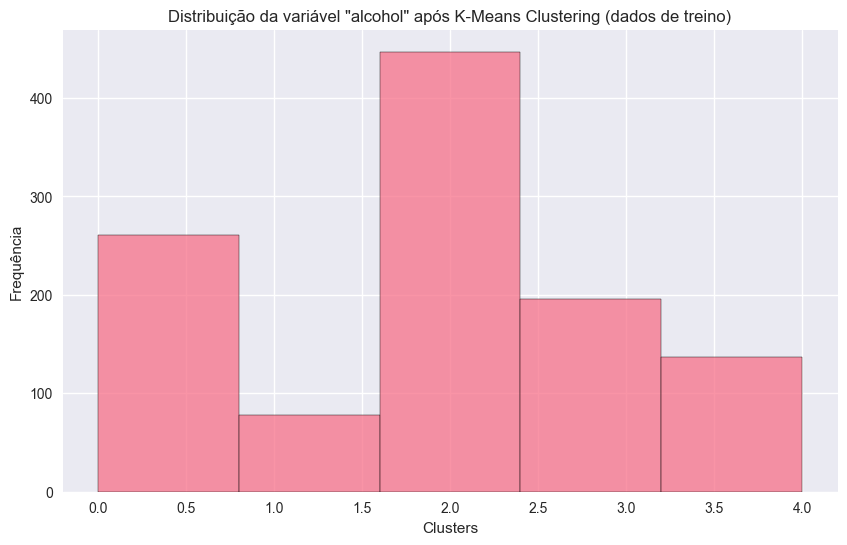

In [12]:
# Plotando a distribuição dos dados discretizados
plt.figure(figsize=(10, 6))
sns.histplot(X_train['alcohol_kmeans'], bins=5, kde=False)
plt.title('Distribuição da variável "alcohol" após K-Means Clustering (dados de treino)')
plt.xlabel('Clusters')
plt.ylabel('Frequência')
plt.show()

# 7. Comparação de Performance em Machine Learning

Nesta seção, vamos comparar o desempenho de um modelo de regressão linear utilizando os dados originais versus os dados discretizados com as diferentes técnicas.

## 7.1. Preparação dos Dados e Função de Avaliação

In [13]:
# Função para treinar o modelo e retornar métricas de desempenho
def train_and_evaluate(X_train, X_test, y_train, y_test):
    """
    Treina um modelo de regressão linear e avalia seu desempenho.

    Parâmetros:
    X_train (pd.DataFrame): Dados de treino (características).
    X_test (pd.DataFrame): Dados de teste (características).
    y_train (pd.Series): Valores de treino (target).
    y_test (pd.Series): Valores de teste (target).

    Retorna:
    dict: Métricas de desempenho (MSE e R²).
    """
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    return {'mse': mse, 'r2': r2}

In [14]:
# Dataset não tratado (dados originais)
X_train_raw = X_train.drop(columns=['alcohol_equal_width', 'alcohol_equal_frequency', 'alcohol_kmeans'])
X_test_raw = X_test.drop(columns=['alcohol_equal_width', 'alcohol_equal_frequency', 'alcohol_kmeans'])

# Dataset tratado com Equal Width Binning
X_train_equal_width = X_train.drop(columns=['alcohol', 'alcohol_equal_frequency', 'alcohol_kmeans'])
X_train_equal_width = X_train_equal_width.rename(columns={'alcohol_equal_width': 'alcohol'})
X_test_equal_width = X_test.drop(columns=['alcohol', 'alcohol_equal_frequency', 'alcohol_kmeans'])
X_test_equal_width = X_test_equal_width.rename(columns={'alcohol_equal_width': 'alcohol'})

# Dataset tratado com Equal Frequency Binning
X_train_equal_frequency = X_train.drop(columns=['alcohol', 'alcohol_equal_width', 'alcohol_kmeans'])
X_train_equal_frequency = X_train_equal_frequency.rename(columns={'alcohol_equal_frequency': 'alcohol'})
X_test_equal_frequency = X_test.drop(columns=['alcohol', 'alcohol_equal_width', 'alcohol_kmeans'])
X_test_equal_frequency = X_test_equal_frequency.rename(columns={'alcohol_equal_frequency': 'alcohol'})

# Dataset tratado com K-Means Clustering
X_train_kmeans = X_train.drop(columns=['alcohol', 'alcohol_equal_width', 'alcohol_equal_frequency'])
X_train_kmeans = X_train_kmeans.rename(columns={'alcohol_kmeans': 'alcohol'})
X_test_kmeans = X_test.drop(columns=['alcohol', 'alcohol_equal_width', 'alcohol_equal_frequency'])
X_test_kmeans = X_test_kmeans.rename(columns={'alcohol_kmeans': 'alcohol'})

## 7.2. Treinamento e Avaliação dos Modelos

In [15]:
results_raw = train_and_evaluate(X_train_raw, X_test_raw, y_train, y_test)
results_equal_width = train_and_evaluate(X_train_equal_width, X_test_equal_width, y_train, y_test)
results_equal_frequency = train_and_evaluate(X_train_equal_frequency, X_test_equal_frequency, y_train, y_test)
results_kmeans = train_and_evaluate(X_train_kmeans, X_test_kmeans, y_train, y_test)

print(f"Desempenho com dados brutos: MSE = {results_raw['mse']:.4f}, R2 = {results_raw['r2']:.4f}")
print(f"Desempenho com Equal Width Binning: MSE = {results_equal_width['mse']:.4f}, R2 = {results_equal_width['r2']:.4f}")
print(f"Desempenho com Equal Frequency Binning: MSE = {results_equal_frequency['mse']:.4f}, R2 = {results_equal_frequency['r2']:.4f}")
print(f"Desempenho com K-Means Clustering: MSE = {results_kmeans['mse']:.4f}, R2 = {results_kmeans['r2']:.4f}")

Desempenho com dados brutos: MSE = 0.4008, R2 = 0.3207
Desempenho com Equal Width Binning: MSE = 0.4045, R2 = 0.3144
Desempenho com Equal Frequency Binning: MSE = 0.4059, R2 = 0.3120
Desempenho com K-Means Clustering: MSE = 0.4293, R2 = 0.2725


## 7.3. Visualização Comparativa dos Resultados

Text(0.5, 1.0, 'K-Means Clustering')

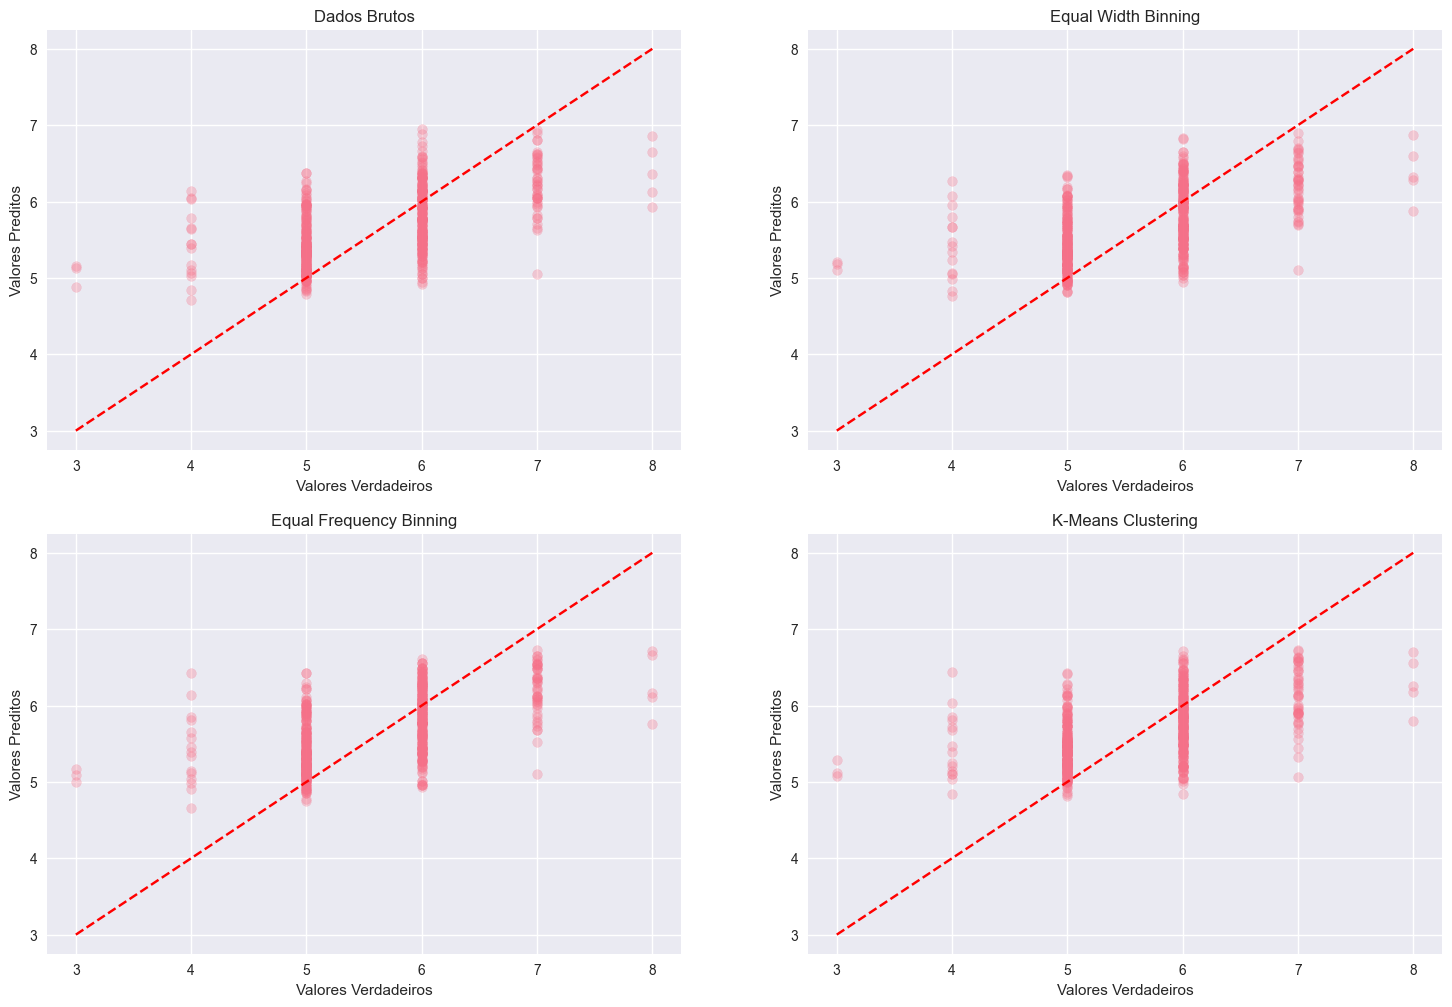

In [16]:
plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
plt.scatter(y_test, LinearRegression().fit(X_train_raw, y_train).predict(X_test_raw), alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.xlabel('Valores Verdadeiros')
plt.ylabel('Valores Preditos')
plt.title('Dados Brutos')

plt.subplot(2, 2, 2)
plt.scatter(y_test, LinearRegression().fit(X_train_equal_width, y_train).predict(X_test_equal_width), alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.xlabel('Valores Verdadeiros')
plt.ylabel('Valores Preditos')
plt.title('Equal Width Binning')

plt.subplot(2, 2, 3)
plt.scatter(y_test, LinearRegression().fit(X_train_equal_frequency, y_train).predict(X_test_equal_frequency), alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.xlabel('Valores Verdadeiros')
plt.ylabel('Valores Preditos')
plt.title('Equal Frequency Binning')

plt.subplot(2, 2, 4)
plt.scatter(y_test, LinearRegression().fit(X_train_kmeans, y_train).predict(X_test_kmeans), alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.xlabel('Valores Verdadeiros')
plt.ylabel('Valores Preditos')
plt.title('K-Means Clustering')

# 8. Conclusões e Considerações Finais

## 8.1. Resumo dos Resultados

Neste notebook, exploramos três técnicas principais de discretização de variáveis numéricas aplicadas ao dataset Wine Quality:

### **Técnicas Implementadas:**
1. **Equal Width Binning:** Divisão em intervalos de largura igual
2. **Equal Frequency Binning:** Divisão em intervalos com frequência balanceada  
3. **K-Means Clustering:** Discretização baseada em agrupamento

### **Principais Descobertas:**
- Cada técnica de discretização produz diferentes distribuições dos dados
- O impacto na performance do modelo varia dependendo da técnica utilizada
- A escolha da técnica deve considerar a natureza dos dados e o objetivo do problema

## 8.2. Quando Utilizar Cada Técnica

### **Equal Width Binning:**
- **Vantagens:** Simples de implementar e interpretar
- **Quando usar:** Dados com distribuição relativamente uniforme
- **Cuidados:** Pode criar bins com frequências muito desbalanceadas

### **Equal Frequency Binning:**
- **Vantagens:** Garante distribuição balanceada entre os bins
- **Quando usar:** Dados com distribuições assimétricas ou com outliers
- **Cuidados:** Os intervalos podem ter larguras muito diferentes

### **K-Means Clustering:**
- **Vantagens:** Considera a estrutura natural dos dados
- **Quando usar:** Dados com agrupamentos naturais ou distribuições complexas
- **Cuidados:** Mais complexo computacionalmente e sensível à inicialização

## 8.3. Considerações para Projetos Reais

- **Análise Exploratória:** Sempre visualize a distribuição original dos dados
- **Validação:** Compare a performance com dados originais vs. discretizados
- **Domínio:** Considere o conhecimento do domínio na escolha dos bins
- **Interpretabilidade:** Avalie se a discretização facilita a interpretação dos resultados

## 8.4. Reflexões Avançadas sobre Discretização

### **Impacto na Interpretabilidade:**
A discretização de variáveis numéricas oferece vantagens únicas na interpretabilidade de modelos de machine learning:
- **Regras de negócio claras:** Bins podem ser traduzidos em políticas práticas
- **Detecção de padrões:** Facilita identificação de thresholds críticos
- **Comunicação:** Executivos compreendem melhor "faixas" do que valores contínuos

### **Considerações Estatísticas:**
- **Perda de informação:** Discretização sempre resulta em alguma perda de granularidade
- **Bias introduzido:** Escolha de bins pode introduzir viés no modelo
- **Robustez:** Modelos discretizados podem ser mais robustos a outliers

## 8.5. Lições Práticas para Projetos Reais

### **Validação de Métodos:**
1. **Sempre compare:** Performance com e sem discretização
2. **Cross-validation:** Use validação cruzada para escolha de número de bins
3. **Métricas específicas:** Considere métricas apropriadas ao problema de negócio
4. **Análise de sensibilidade:** Teste diferentes configurações de bins

### **Escolha da Técnica:**
- **Equal Width:** Para distribuições uniformes ou quando interpretabilidade é crítica
- **Equal Frequency:** Para distribuições assimétricas ou quando balanceamento é importante
- **K-Means:** Para dados com agrupamentos naturais ou padrões complexos

### **Armadilhas Comuns:**
- **Discretizar sem análise exploratória prévia**
- **Usar número fixo de bins sem validação**
- **Ignorar a distribuição original dos dados**
- **Não considerar o conhecimento de domínio**

## 8.6. Integração com Pipeline de ML

### **Preprocessamento Robusto:**
- **Scalabilidade:** Técnicas escolhidas devem funcionar com novos dados
- **Versionamento:** Parâmetros de discretização devem ser versionados
- **Monitoramento:** Distribuições podem mudar ao longo do tempo (concept drift)

### **Feature Engineering Avançado:**
- **Combinação com outras técnicas:** Discretização + feature crossing
- **Feature selection:** Nem todas as variáveis discretizadas agregam valor
- **Ensemble methods:** Diferentes discretizações para diferentes modelos

## 8.7. Considerações Éticas e de Fairness

### **Viés em Discretização:**
- Bins podem amplificar vieses existentes nos dados
- Importante avaliar fairness entre diferentes grupos demográficos
- Considerar impacto de thresholds em decisões sensíveis

### **Transparência:**
- Documentar critérios de escolha de bins
- Explicar impacto da discretização em stakeholders
- Manter rastreabilidade das transformações

---

### **Mensagem Final**
A **discretização** é uma ferramenta poderosa que, quando aplicada corretamente, pode **simplificar modelos complexos**, **melhorar a interpretabilidade** e **capturar padrões não-lineares**. A chave está em **equilibrar a simplicidade com a preservação da informação relevante**, sempre validando o impacto nas métricas de negócio.

### **Para Saber Mais**
- Explore técnicas avançadas como discretização supervisionada (ChiMerge, MDLP)
- Estude o impacto da discretização em diferentes algoritmos de ML
- Pratique com datasets de diferentes domínios para desenvolver intuição